In [1]:
#@title Default title text
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#!ls 'drive/My Drive/local training'
import os
os.chdir('drive/My Drive/Doktora/TBC/Mescere')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [3]:
data = pd.read_excel('kuru_ladin_mescere_parametre.xlsx')

In [4]:
data

,treeID,Ağaç No,Yükseklik (m),Gövde Çapı (cm),Canopy Çapı (m),Canopy Alanı (m2)
0,10,L.6,22.971,49,4.015,7.694
1,582,L.8,16.932,34,2.527,2.537
2,431,L.9,17.620,35,2.248,1.674
3,385,L.5,16.308,28,3.447,2.275
4,7,L.12,16.985,45,3.684,5.040
5,335,L.22,14.368,31,2.549,1.542
6,1041,L.21,16.280,29,3.200,2.414
7,1316,L.19,13.808,34,3.204,2.436
8,1093,L.13,17.521,35,4.323,4.854
9,14,L.32,12.446,24,0.204,1.282


Regresyon eğrisinin uzağında kalan değerler:
Empty DataFrame
Columns: [treeID, Ağaç No, Yükseklik (m), Gövde Çapı (cm), Canopy Çapı (m), Canopy Alanı (m2)]
Index: []


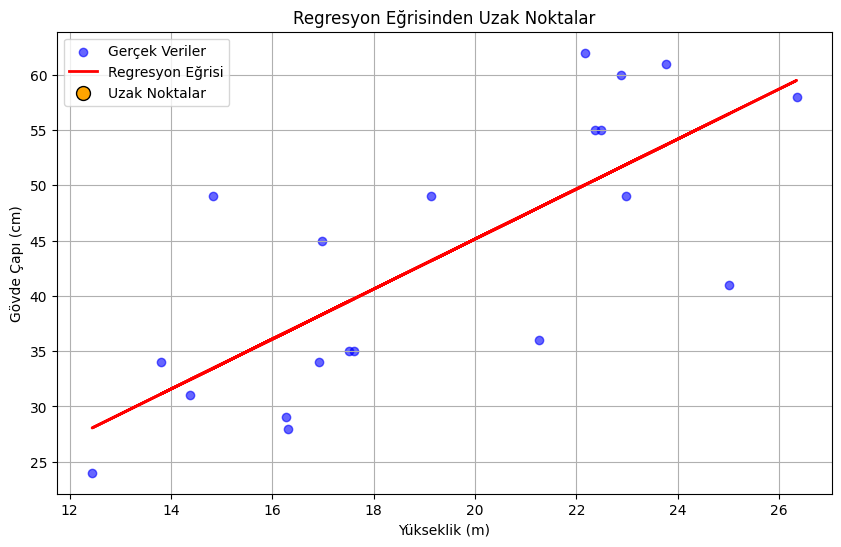

In [5]:
# Veri setini tanımlama
X = data[['Yükseklik (m)']].values  # Bağımsız değişken
y = data['Gövde Çapı (cm)'].values  # Bağımlı değişken

# Doğrusal regresyon modeli oluşturma
model = LinearRegression()
model.fit(X, y)

# Tahmin edilen değerleri hesaplama
y_pred = model.predict(X)

# Sapmaları hesaplama
residuals = y - y_pred

# Sapmalar için eşik belirleme (Z-skoru)
z_scores = (residuals - np.mean(residuals)) / np.std(residuals)
threshold = 2  # Z-skoru için eşik (örneğin, 3)

# Uzak noktaları tespit etme
outliers = data[np.abs(z_scores) > threshold]

print("Regresyon eğrisinin uzağında kalan değerler:")
print(outliers)

# Regresyon eğrisini ve uzak noktaları görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Gerçek Veriler', color='blue', alpha=0.6)
plt.plot(X, y_pred, label='Regresyon Eğrisi', color='red', linewidth=2)
plt.scatter(X[np.abs(z_scores) > threshold], y[np.abs(z_scores) > threshold],
            label='Uzak Noktalar', color='orange', edgecolor='black', s=100)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Regresyon Eğrisinden Uzak Noktalar')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
thresholds = [1.5, 2, 3]

for threshold in thresholds:
    outliers = data[np.abs(z_scores) > threshold]
    print(f"Z-Skoru Eşiği: {threshold}")
    print(f"Uç Nokta Sayısı: {len(outliers)}")
    print(outliers)
    print("-" * 50)

Z-Skoru Eşiği: 1.5
Uç Nokta Sayısı: 4
    treeID Ağaç No  Yükseklik (m)  Gövde Çapı (cm)  Canopy Çapı (m)  \
10      12    L.20         25.011               41            4.081   
13    1055   L.308         21.270               36            4.584   
14    1317   L.317         14.840               49            2.810   
15    1094    L.94         22.176               62            3.485   

    Canopy Alanı (m2)  
10              4.228  
13              4.273  
14              2.054  
15              3.832  
--------------------------------------------------
Z-Skoru Eşiği: 2
Uç Nokta Sayısı: 0
Empty DataFrame
Columns: [treeID, Ağaç No, Yükseklik (m), Gövde Çapı (cm), Canopy Çapı (m), Canopy Alanı (m2)]
Index: []
--------------------------------------------------
Z-Skoru Eşiği: 3
Uç Nokta Sayısı: 0
Empty DataFrame
Columns: [treeID, Ağaç No, Yükseklik (m), Gövde Çapı (cm), Canopy Çapı (m), Canopy Alanı (m2)]
Index: []
--------------------------------------------------


In [8]:
data = pd.read_excel('kuru_ladin-1-5.xlsx')

In [9]:
data

,treeID,Ağaç No,Yükseklik (m),Gövde Çapı (cm),Canopy Çapı (m),Canopy Alanı (m2)
0,10,L.6,22.971,49,4.015,7.694
1,582,L.8,16.932,34,2.527,2.537
2,431,L.9,17.620,35,2.248,1.674
3,385,L.5,16.308,28,3.447,2.275
4,7,L.12,16.985,45,3.684,5.040
5,335,L.22,14.368,31,2.549,1.542
6,1041,L.21,16.280,29,3.200,2.414
7,1316,L.19,13.808,34,3.204,2.436
8,1093,L.13,17.521,35,4.323,4.854
9,14,L.32,12.446,24,0.204,1.282


In [11]:
# 1. Korelasyon matrisi oluşturma
selected_columns = ['Yükseklik (m)', 'Gövde Çapı (cm)', 'Canopy Çapı (m)', 'Canopy Alanı (m2)']
correlation_matrix = data[selected_columns].corr()

In [12]:
# 2. Korelasyon matrisini yazdırma
print("Korelasyon Matrisi:")
print(correlation_matrix)

Korelasyon Matrisi:
                   Yükseklik (m)  Gövde Çapı (cm)  Canopy Çapı (m)  \
Yükseklik (m)           1.000000         0.916133         0.439485   
Gövde Çapı (cm)         0.916133         1.000000         0.449119   
Canopy Çapı (m)         0.439485         0.449119         1.000000   
Canopy Alanı (m2)       0.267100         0.326939         0.793416   

                   Canopy Alanı (m2)  
Yükseklik (m)               0.267100  
Gövde Çapı (cm)             0.326939  
Canopy Çapı (m)             0.793416  
Canopy Alanı (m2)           1.000000  


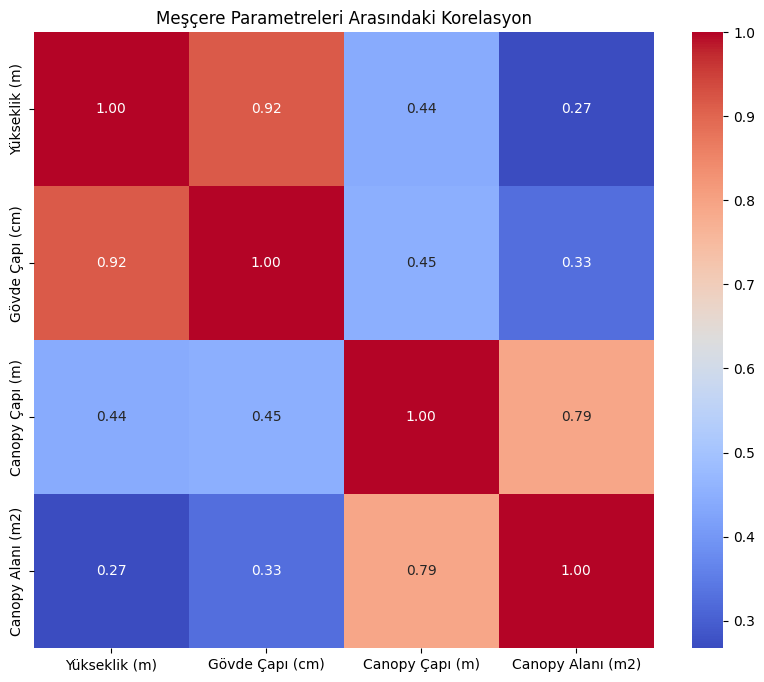

In [13]:
# 3. Korelasyon matrisini görselleştirme (Isı haritası)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Meşçere Parametreleri Arasındaki Korelasyon')
plt.show()

Regresyon Formülü: Gövde Çapı (cm) = 2.85 * Yükseklik (m) + -11.24
Doğrusal Regresyon Modeli Performansı:
R²: 0.84
MAE: 4.46 (Ortalama Mutlak Hata)
MSE: 24.26 (Ortalama Kare Hata)

Yükseklik 20 metre için tahmini Gövde Çapı: 45.79 cm


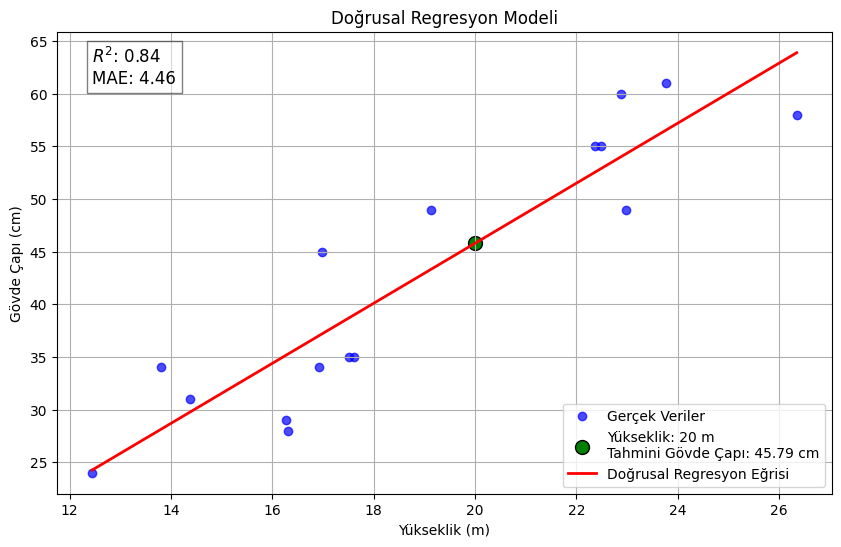

In [14]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Model tanımlama ve eğitme
lr_model = LinearRegression()
lr_model.fit(X, y)

# Modelin katsayılarını ve kesişimini öğrenme
a = lr_model.coef_[0]  # Katsayı
b = lr_model.intercept_  # Kesişim noktası
print(f"Regresyon Formülü: Gövde Çapı (cm) = {a:.2f} * Yükseklik (m) + {b:.2f}")

# Tahminler
y_pred_lr = lr_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_lr)
mae = mean_absolute_error(y, y_pred_lr)
mse = mean_squared_error(y, y_pred_lr)

# Model performansını yazdırma
print(f"Doğrusal Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 20  # Örnek yükseklik değeri
predicted_diameter = lr_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve doğrusal regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = lr_model.predict(X_curve)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 20 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='Doğrusal Regresyon Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Doğrusal Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

Polinomsal Regresyon Formülü: Gövde Çapı (cm) = -0.02 * Yükseklik² + 3.73 * Yükseklik + -19.36
Polinomsal Regresyon Modeli Performansı (Derece 2):
R²: 0.84
MAE: 4.47 (Ortalama Mutlak Hata)
MSE: 24.15 (Ortalama Kare Hata)

Yükseklik 20 metre için tahmini Gövde Çapı: 46.14 cm


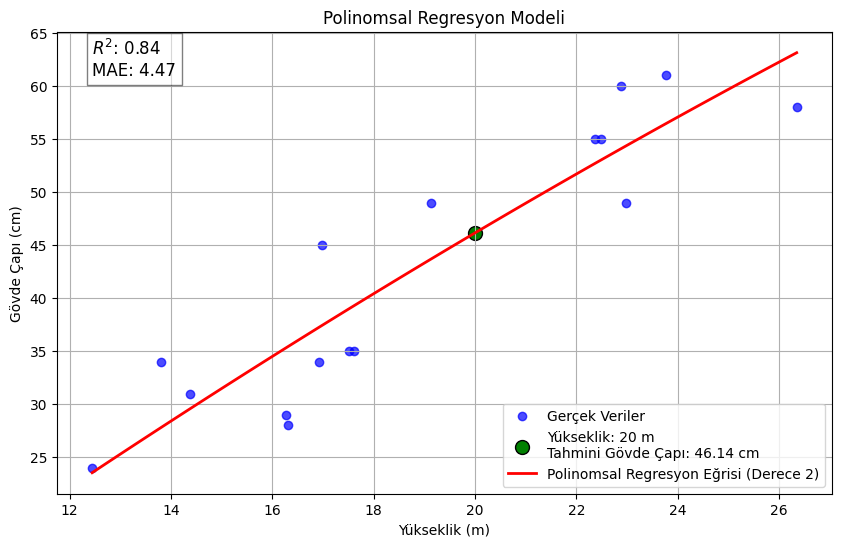

In [15]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Polinom özellikler oluşturma (derece 2)
degree = 2
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)

# Model tanımlama ve eğitme
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Polinomsal regresyon formülü öğrenme
coefficients = poly_model.coef_
intercept = poly_model.intercept_
formula = f"Gövde Çapı (cm) = {coefficients[2]:.2f} * Yükseklik² + {coefficients[1]:.2f} * Yükseklik + {intercept:.2f}"
print(f"Polinomsal Regresyon Formülü: {formula}")

# Tahminler
y_pred_poly = poly_model.predict(X_poly)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_poly)
mae = mean_absolute_error(y, y_pred_poly)
mse = mean_squared_error(y, y_pred_poly)

# Model performansını yazdırma
print(f"Polinomsal Regresyon Modeli Performansı (Derece {degree}):")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 20  # Örnek yükseklik değeri
user_height_poly = poly.transform([[user_height]])
predicted_diameter = poly_model.predict(user_height_poly)
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve polinomsal regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_curve_poly = poly.transform(X_curve)
y_curve = poly_model.predict(X_curve_poly)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 20 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label=f'Polinomsal Regresyon Eğrisi (Derece {degree})', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Polinomsal Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

Logaritmik Regresyon Formülü: Gövde Çapı (cm) = 53.01 * ln(Yükseklik) + -111.98
Logaritmik Regresyon Modeli Performansı:
R²: 0.83
MAE: 4.68 (Ortalama Mutlak Hata)
MSE: 25.51 (Ortalama Kare Hata)

Yükseklik 20 metre için tahmini Gövde Çapı: 46.83 cm


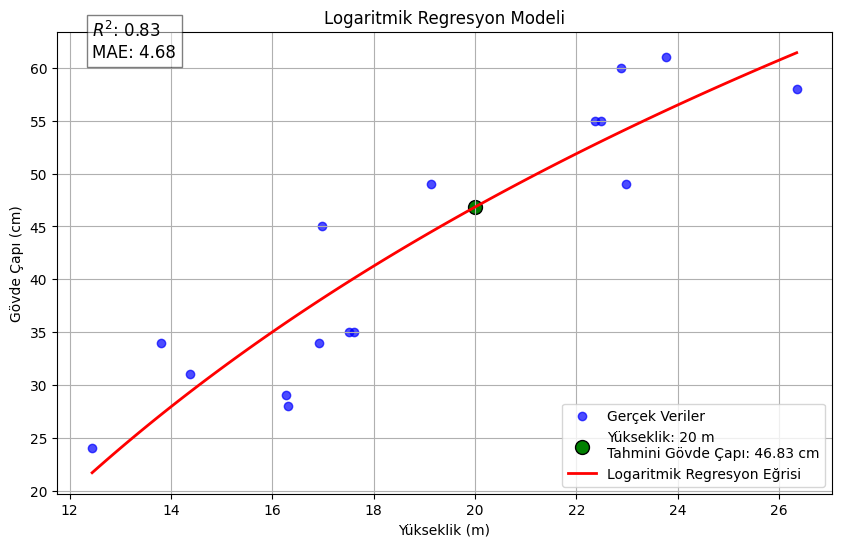

In [16]:
# Bağımsız ve bağımlı değişkenleri ayırma (logaritmik dönüşüm)
X = np.log(data['Yükseklik (m)'].values).reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Model tanımlama ve eğitme
log_model = LinearRegression()
log_model.fit(X, y)

# Logaritmik regresyon formülü öğrenme
a = log_model.coef_[0]  # Katsayı
b = log_model.intercept_  # Kesişim noktası
formula = f"Gövde Çapı (cm) = {a:.2f} * ln(Yükseklik) + {b:.2f}"
print(f"Logaritmik Regresyon Formülü: {formula}")

# Tahminler
y_pred_log = log_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_log)
mae = mean_absolute_error(y, y_pred_log)
mse = mean_squared_error(y, y_pred_log)

# Model performansını yazdırma
print(f"Logaritmik Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 20  # Örnek yükseklik değeri
user_log_height = np.log(user_height).reshape(1, -1)
predicted_diameter = log_model.predict(user_log_height)
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve logaritmik regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(data['Yükseklik (m)'], y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(data['Yükseklik (m)'].min(), data['Yükseklik (m)'].max(), 100).reshape(-1, 1)
X_curve_log = np.log(X_curve)
y_curve = log_model.predict(X_curve_log)

# R² değerini grafiğin üzerine ekleme
plt.text(x=data['Yükseklik (m)'].min(), y=max(y), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 20 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='Logaritmik Regresyon Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Logaritmik Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

Destek Vektör Regresyon Modeli Performansı:
R²: 0.89
MAE: 2.43 (Ortalama Mutlak Hata)
MSE: 16.89 (Ortalama Kare Hata)

Yükseklik 20 metre için tahmini Gövde Çapı: 51.01 cm


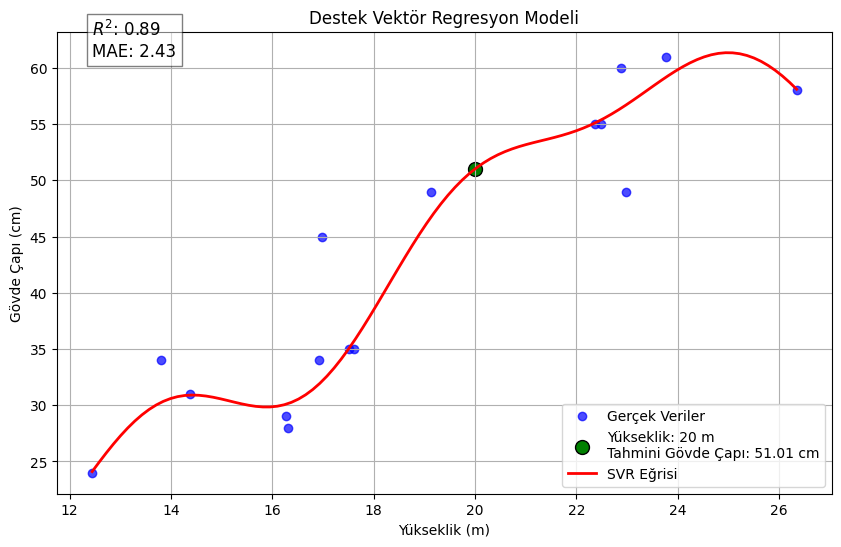

In [17]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Destek Vektör Regresyon modeli tanımlama ve eğitme
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X, y)

# Tahminler
y_pred_svr = svr_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_svr)
mae = mean_absolute_error(y, y_pred_svr)
mse = mean_squared_error(y, y_pred_svr)

# Model performansını yazdırma
print(f"Destek Vektör Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 20  # Örnek yükseklik değeri
predicted_diameter = svr_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve SVR eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = svr_model.predict(X_curve)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=max(y), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 20 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='SVR Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Destek Vektör Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

RandomForest Regressor Modeli Performansı:
R²: 0.96
MAE: 1.88 (Ortalama Mutlak Hata)
MSE: 5.79 (Ortalama Kare Hata)

Yükseklik 20 metre için tahmini Gövde Çapı: 49.66 cm


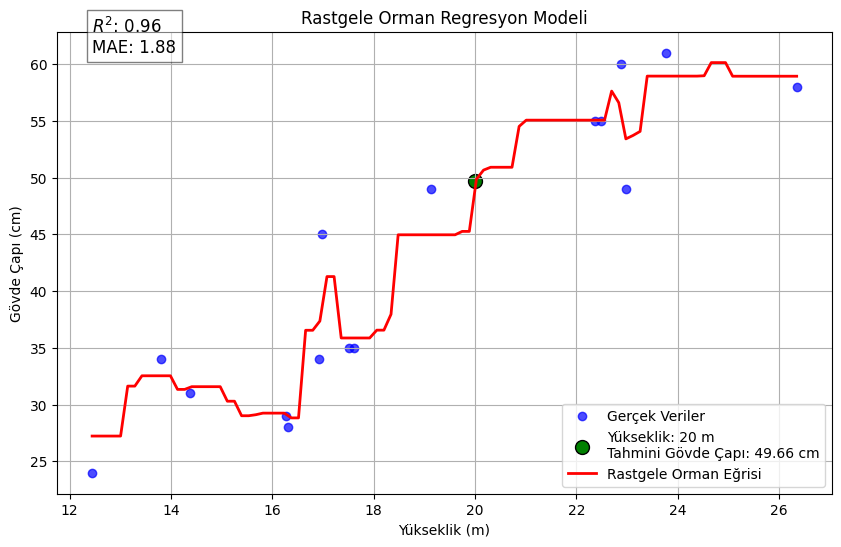

In [18]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Model tanımlama ve eğitme
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Tahminler
y_pred_rf = rf_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_rf)
mae = mean_absolute_error(y, y_pred_rf)
mse = mean_squared_error(y, y_pred_rf)

# Model performansını yazdırma
print(f"RandomForest Regressor Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 20  # Örnek yükseklik değeri
predicted_diameter = rf_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve RandomForest regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = rf_model.predict(X_curve)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 20 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='Rastgele Orman Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Rastgele Orman Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

XGBoost Regresyon Modeli Performansı:
R²: 1.00
MAE: 0.25 (Ortalama Mutlak Hata)
MSE: 0.10 (Ortalama Kare Hata)

Yükseklik 20 metre için tahmini Gövde Çapı: 49.03 cm


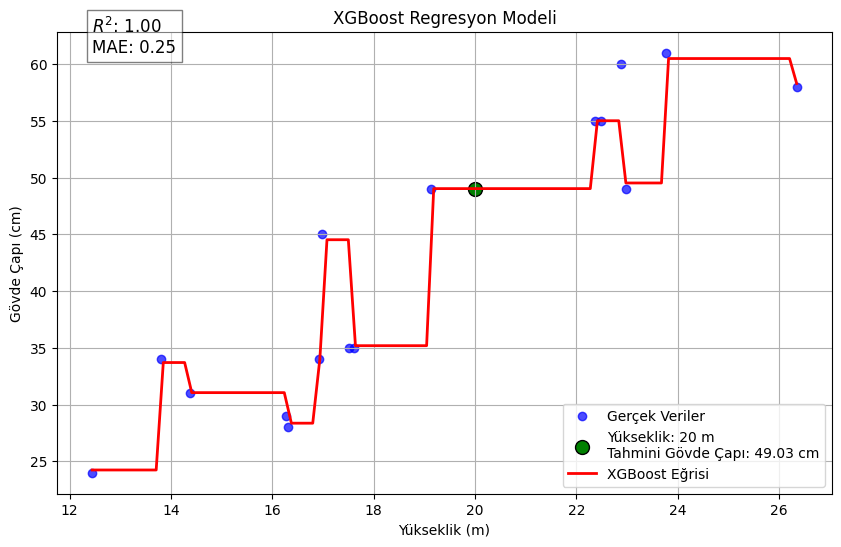

In [19]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# XGBoost Regresyon modeli tanımlama ve eğitme
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X, y)

# Tahminler
y_pred_xgb = xgb_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_xgb)
mae = mean_absolute_error(y, y_pred_xgb)
mse = mean_squared_error(y, y_pred_xgb)

# Model performansını yazdırma
print(f"XGBoost Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 20  # Örnek yükseklik değeri
predicted_diameter = xgb_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve XGBoost eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = xgb_model.predict(X_curve)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=max(y), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 20 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='XGBoost Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('XGBoost Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

In [20]:
# Uç değerleri bulmak için alt ve üst sınırları hesaplama
Q1 = data['Yükseklik (m)'].quantile(0.25)  # 1. Çeyrek
Q3 = data['Yükseklik (m)'].quantile(0.75)  # 3. Çeyrek
IQR = Q3 - Q1  # Çeyrekler arası aralık

# Alt ve üst sınırlar
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Yükseklik için uç değerleri kaldırma
data_no_outliers = data[(data['Yükseklik (m)'] >= lower_bound) & (data['Yükseklik (m)'] <= upper_bound)]

# Aynı işlemi gövde çapı için yapabilirsiniz
Q1_diameter = data['Gövde Çapı (cm)'].quantile(0.25)
Q3_diameter = data['Gövde Çapı (cm)'].quantile(0.75)
IQR_diameter = Q3_diameter - Q1_diameter

lower_bound_diameter = Q1_diameter - 1.5 * IQR_diameter
upper_bound_diameter = Q3_diameter + 1.5 * IQR_diameter

data_no_outliers = data_no_outliers[
    (data_no_outliers['Gövde Çapı (cm)'] >= lower_bound_diameter) &
    (data_no_outliers['Gövde Çapı (cm)'] <= upper_bound_diameter)
]


<ipython-input-21-39f692ecab9d>:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


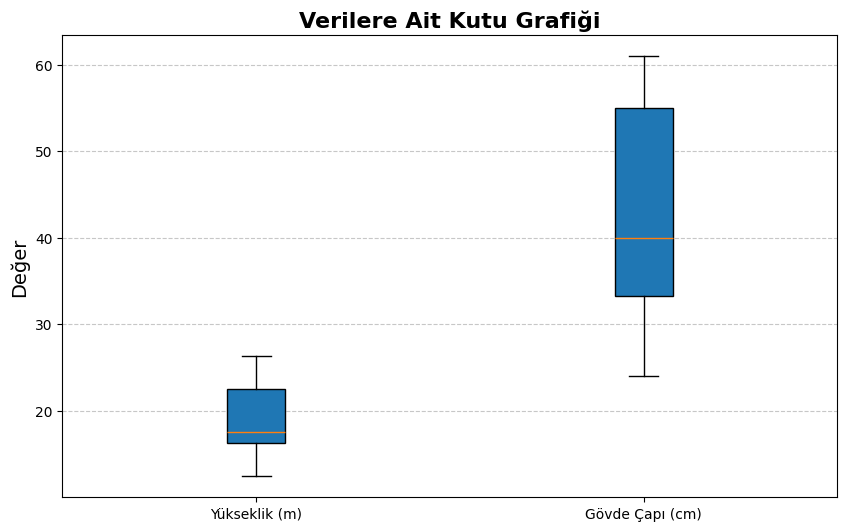

In [21]:
# Uç değerleri kaldırılmış veriyle kutu grafiği
plt.figure(figsize=(10, 6))
plt.boxplot(
    [data_no_outliers['Yükseklik (m)'], data_no_outliers['Gövde Çapı (cm)']],
    labels=['Yükseklik (m)', 'Gövde Çapı (cm)'],
    patch_artist=True
)

# Grafik detayları
plt.title('Verilere Ait Kutu Grafiği', fontsize=16, fontweight='bold')
plt.ylabel('Değer', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()